# NIVEL FÁCIL - Calidad de Datos en SISMEPRE

---

## Contexto del Negocio

### Descripción del Problema
**SISMEPRE**, como fuente de información para el seguimiento de formularios, preguntas y respuestas estadísticas, requiere validar la calidad de sus registros en la capa silver. El dataset contiene información de entidades ejecutoras, formularios, periodos, estados, fechas de creación, resoluciones adjuntas y respuestas asociadas.

### Objetivo Analítico
Evaluar y mejorar la calidad de los datos del archivo `SISMEPRE_CAPA_SILVER.csv` para:
- Generar reportes confiables por entidad ejecutora y formulario
- Validar respuestas, fechas y estados registrados
- Identificar valores inconsistentes, duplicados o fuera de rango

### Impacto de la Mala Calidad de Datos
- **Operativo**: Registros incompletos o con fechas inválidas pueden afectar el seguimiento de formularios
- **Analítico**: Valores inconsistentes en respuestas dificultan el análisis estadístico
- **Estratégico**: Estados o clasificaciones incorrectas pueden llevar a conclusiones erróneas sobre el avance reportado

---

## Dimensiones de Calidad a Evaluar

En este caso trabajaremos con:

1. **Completitud**: ¿Tenemos valores faltantes o campos vacíos?
2. **Exactitud**: ¿Los valores numéricos y categóricos son válidos?
3. **Consistencia**: ¿Existe coherencia entre campos relacionados?
4. **Integridad**: ¿Los identificadores y claves cumplen rangos esperados?
5. **Razonabilidad**: ¿Los valores se encuentran dentro de rangos esperados?
6. **Oportunidad**: ¿Las fechas son válidas y coherentes con el periodo?
7. **Unicidad**: ¿Existen registros duplicados?
8. **Validez**: ¿Los formatos y dominios permitidos se cumplen?

In [1]:
# Instalación de librerías necesarias
# !pip install pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


## Carga del Dataset

Cargaremos el dataset SISMEPRE de la capa silver con 100,000 registros.

In [2]:
# Cargar datos desde el archivo CSV
df = pd.read_csv('SISMEPRE_CAPA_SILVER.csv')

# Convertir campos de fecha al formato datetime
df['USUARIO_CREACION_FECHA'] = pd.to_datetime(df['USUARIO_CREACION_FECHA'], errors='coerce')
df['FECHA_RESOL_ALCAL_ADJUNTO_DT'] = pd.to_datetime(
    df['FECHA_RESOL_ALCAL_ADJUNTO'].replace('0', np.nan).replace(' ', np.nan),
    errors='coerce',
    dayfirst=True
)
df['RESPUESTA_FECHA_DT'] = pd.to_datetime(
    df['RESPUESTA_FECHA'].replace(' ', np.nan),
    errors='coerce',
    dayfirst=True
)

print(f"Dataset cargado con {len(df):,} registros")
print(f"Columnas: {list(df.columns)}")
print(f"\nRango de fechas de creación: {df['USUARIO_CREACION_FECHA'].min().date()} a {df['USUARIO_CREACION_FECHA'].max().date()}")

Dataset cargado con 100,000 registros
Columnas: ['SEC_EJEC', 'ANO_APLICACION', 'USUARIO_CREACION_FECHA', 'ESTADO', 'USUARIO_ENVIO_ID', 'USUARIO_FECHA_ENVIO', 'CORREO', 'ORIGEN_INFORMACION', 'CLASIFICACION', 'PERIODO', 'TIPO_META', 'IND_RESOL_ALCAL_ADJUNTO', 'FECHA_RESOL_ALCAL_ADJUNTO', 'FORMULARIO_ID', 'ANO_ESTADISTICA', 'MES_ESTADISTICA', 'ESTADO_REGISTRO', 'ANO_ESTADISTICA_DESC', 'SEC_EJEC_1', 'FORMULARIO_ID_1', 'PREGUNTA_ID', 'RESPUESTA_ID', 'RESPUESTA_TEXTO', 'RESPUESTA_DECIMAL', 'RESPUESTA_ENTERO', 'RESPUESTA_FECHA', 'ESTADO_REGISTRO_1', 'FECHA_RESOL_ALCAL_ADJUNTO_DT', 'RESPUESTA_FECHA_DT']

Rango de fechas de creación: 2022-01-25 a 2022-01-25


In [3]:
# Vista previa del dataset
df.head(10)

,SEC_EJEC,ANO_APLICACION,USUARIO_CREACION_FECHA,ESTADO,USUARIO_ENVIO_ID,USUARIO_FECHA_ENVIO,CORREO,ORIGEN_INFORMACION,CLASIFICACION,PERIODO,TIPO_META,IND_RESOL_ALCAL_ADJUNTO,FECHA_RESOL_ALCAL_ADJUNTO,FORMULARIO_ID,ANO_ESTADISTICA,MES_ESTADISTICA,ESTADO_REGISTRO,ANO_ESTADISTICA_DESC,SEC_EJEC_1,FORMULARIO_ID_1,PREGUNTA_ID,RESPUESTA_ID,RESPUESTA_TEXTO,RESPUESTA_DECIMAL,RESPUESTA_ENTERO,RESPUESTA_FECHA,ESTADO_REGISTRO_1,FECHA_RESOL_ALCAL_ADJUNTO_DT,RESPUESTA_FECHA_DT
0,301003,2022,2022-01-25 18:20:51,A,0,,,1,A,1,2,A,31/03/2022 16:54:51,8,2021,13,A,2021,301071,5,86,75,0,0.0,0,,A,2022-03-31 16:54:51,NaT
1,301046,2022,2022-01-25 18:20:52,A,0,,,1,A,1,2,A,15/02/2022 10:20:49,8,2021,13,A,2021,301071,5,86,75,0,0.0,0,,A,2022-02-15 10:20:49,NaT
2,301052,2022,2022-01-25 18:20:52,A,0,,,1,A,1,2,A,28/03/2022 08:23:21,8,2021,13,A,2021,301071,5,86,75,0,0.0,0,,A,2022-03-28 08:23:21,NaT
3,301090,2022,2022-01-25 18:20:52,A,0,,,1,A,1,2,A,31/03/2022 09:00:04,8,2021,13,A,2021,301071,5,86,75,0,0.0,0,,A,2022-03-31 09:00:04,NaT
4,301098,2022,2022-01-25 18:20:52,A,0,,,1,A,1,2,P,0,8,2021,13,A,2021,301071,5,86,75,0,0.0,0,,A,NaT,NaT
5,301108,2022,2022-01-25 18:20:52,A,0,,,1,A,1,2,A,29/03/2022 16:26:53,8,2021,13,A,2021,301071,5,86,75,0,0.0,0,,A,2022-03-29 16:26:53,NaT
6,301118,2022,2022-01-25 18:20:52,A,0,,,1,A,1,2,A,29/03/2022 12:49:04,8,2021,13,A,2021,301071,5,86,75,0,0.0,0,,A,2022-03-29 12:49:04,NaT
7,301127,2022,2022-01-25 18:20:52,A,0,,,1,A,1,2,A,11/03/2022 15:34:42,8,2021,13,A,2021,301071,5,86,75,0,0.0,0,,A,2022-03-11 15:34:42,NaT
8,301154,2022,2022-01-25 18:20:52,A,0,,,1,A,1,2,A,31/03/2022 09:30:07,8,2021,13,A,2021,301071,5,86,75,0,0.0,0,,A,2022-03-31 09:30:07,NaT
9,301189,2022,2022-01-25 18:20:52,A,0,,,1,A,1,2,A,31/03/2022 17:53:17,8,2021,13,A,2021,301071,5,86,75,0,0.0,0,,A,2022-03-31 17:53:17,NaT


In [4]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 29 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   SEC_EJEC                      100000 non-null  int64         
 1   ANO_APLICACION                100000 non-null  int64         
 2   USUARIO_CREACION_FECHA        100000 non-null  datetime64[ns]
 3   ESTADO                        100000 non-null  object        
 4   USUARIO_ENVIO_ID              100000 non-null  int64         
 5   USUARIO_FECHA_ENVIO           100000 non-null  object        
 6   CORREO                        100000 non-null  object        
 7   ORIGEN_INFORMACION            100000 non-null  int64         
 8   CLASIFICACION                 100000 non-null  object        
 9   PERIODO                       100000 non-null  int64         
 10  TIPO_META                     100000 non-null  int64         
 11  IND_RESOL_ALCA

---

## Análisis de Calidad de Datos

### 1. COMPLETITUD - Análisis de Datos Faltantes

ANÁLISIS DE COMPLETITUD
                              Faltantes  Porcentaje
USUARIO_FECHA_ENVIO              100000     100.000
CORREO                           100000     100.000
RESPUESTA_FECHA                   99575      99.575
RESPUESTA_FECHA_DT                99575      99.575
FECHA_RESOL_ALCAL_ADJUNTO_DT      37633      37.633


<Figure size 1000x600 with 0 Axes>

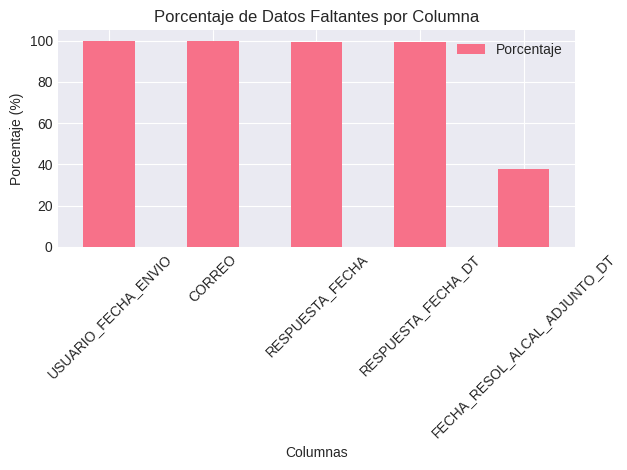

In [5]:
# Calcular porcentaje de valores faltantes considerando nulos y campos vacíos
df_limpio = df.replace(r'^\s*$', np.nan, regex=True)

missing_data = df_limpio.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

# Crear DataFrame con resultados
completitud = pd.DataFrame({
    'Faltantes': missing_data,
    'Porcentaje': missing_percent
}).sort_values('Porcentaje', ascending=False)

print("ANÁLISIS DE COMPLETITUD")
print(completitud[completitud['Faltantes'] > 0])

# Visualización
plt.figure(figsize=(10, 6))
completitud[completitud['Porcentaje'] > 0].plot(kind='bar', y='Porcentaje')
plt.title('Porcentaje de Datos Faltantes por Columna')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Columnas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2. EXACTITUD - Validación de Valores Numéricos

In [6]:
# Detectar valores numéricos incorrectos
anios_invalidos = df[df['ANO_APLICACION'] != 2022]
meses_invalidos = df[~df['MES_ESTADISTICA'].between(1, 12)]
respuestas_negativas = df[(df['RESPUESTA_DECIMAL'] < 0) | (df['RESPUESTA_ENTERO'] < 0)]


print("ANÁLISIS DE EXACTITUD")

print(f"Años de aplicación inválidos: {len(anios_invalidos):,} ({len(anios_invalidos)/len(df)*100:.2f}%)")
print(f"Meses estadísticos inválidos: {len(meses_invalidos):,} ({len(meses_invalidos)/len(df)*100:.2f}%)")
print(f"Respuestas numéricas negativas: {len(respuestas_negativas):,} ({len(respuestas_negativas)/len(df)*100:.2f}%)")

# Mostrar ejemplos
print("\nEjemplos de errores:")
print("\nMeses estadísticos inválidos:")
print(meses_invalidos[['SEC_EJEC', 'ANO_ESTADISTICA', 'MES_ESTADISTICA']].head())
print("\nRespuestas numéricas negativas:")
print(respuestas_negativas[['SEC_EJEC', 'PREGUNTA_ID', 'RESPUESTA_DECIMAL', 'RESPUESTA_ENTERO']].head())

ANÁLISIS DE EXACTITUD
Años de aplicación inválidos: 0 (0.00%)
Meses estadísticos inválidos: 100,000 (100.00%)
Respuestas numéricas negativas: 0 (0.00%)

Ejemplos de errores:

Meses estadísticos inválidos:
   SEC_EJEC  ANO_ESTADISTICA  MES_ESTADISTICA
0    301003             2021               13
1    301046             2021               13
2    301052             2021               13
3    301090             2021               13
4    301098             2021               13

Respuestas numéricas negativas:
Empty DataFrame
Columns: [SEC_EJEC, PREGUNTA_ID, RESPUESTA_DECIMAL, RESPUESTA_ENTERO]
Index: []


### 3. CONSISTENCIA - Coherencia entre Campos

In [7]:
# Validar coherencia entre indicador de resolución y fecha adjunta
df['tiene_fecha_resolucion'] = df['FECHA_RESOL_ALCAL_ADJUNTO_DT'].notna()
resolucion_sin_fecha = df[(df['IND_RESOL_ALCAL_ADJUNTO'] == 'A') & (~df['tiene_fecha_resolucion'])]
fecha_sin_resolucion = df[(df['IND_RESOL_ALCAL_ADJUNTO'] == 'P') & (df['tiene_fecha_resolucion'])]


print("ANÁLISIS DE CONSISTENCIA")
print(f"Resoluciones adjuntas sin fecha válida: {len(resolucion_sin_fecha):,} ({len(resolucion_sin_fecha)/len(df)*100:.2f}%)")
print(f"Registros pendientes con fecha de resolución: {len(fecha_sin_resolucion):,} ({len(fecha_sin_resolucion)/len(df)*100:.2f}%)")

# Verificar coherencia entre año estadístico y descripción
df['anio_desc_esperado'] = df['ANO_ESTADISTICA'].astype(str)
anio_desc_incorrecto = df[df['ANO_ESTADISTICA_DESC'].astype(str) != df['anio_desc_esperado']]

print(f"Año estadístico diferente a descripción: {len(anio_desc_incorrecto):,} ({len(anio_desc_incorrecto)/len(df)*100:.2f}%)")

print("\nEjemplos de inconsistencias:")
print(resolucion_sin_fecha[['SEC_EJEC', 'IND_RESOL_ALCAL_ADJUNTO', 'FECHA_RESOL_ALCAL_ADJUNTO']].head())

ANÁLISIS DE CONSISTENCIA
Resoluciones adjuntas sin fecha válida: 0 (0.00%)
Registros pendientes con fecha de resolución: 0 (0.00%)
Año estadístico diferente a descripción: 0 (0.00%)

Ejemplos de inconsistencias:
Empty DataFrame
Columns: [SEC_EJEC, IND_RESOL_ALCAL_ADJUNTO, FECHA_RESOL_ALCAL_ADJUNTO]
Index: []


### 4. INTEGRIDAD - Validación de IDs

In [8]:
# Rango válido de identificadores según los datos observados
ids_invalidos = df[
    (df['SEC_EJEC'] <= 0) |
    (df['SEC_EJEC_1'] <= 0) |
    (df['FORMULARIO_ID'] <= 0) |
    (df['FORMULARIO_ID_1'] <= 0) |
    (df['PREGUNTA_ID'] <= 0) |
    (df['RESPUESTA_ID'] <= 0)
]


print("ANÁLISIS DE INTEGRIDAD")
print(f"IDs fuera de rango: {len(ids_invalidos):,} ({len(ids_invalidos)/len(df)*100:.2f}%)")

if len(ids_invalidos) > 0:
    print(f"Rango de SEC_EJEC inválidos: {ids_invalidos['SEC_EJEC'].min()} - {ids_invalidos['SEC_EJEC'].max()}")

print("\nEjemplos:")
print(ids_invalidos[['SEC_EJEC', 'SEC_EJEC_1', 'FORMULARIO_ID', 'FORMULARIO_ID_1', 'PREGUNTA_ID', 'RESPUESTA_ID']].head())

ANÁLISIS DE INTEGRIDAD
IDs fuera de rango: 0 (0.00%)

Ejemplos:
Empty DataFrame
Columns: [SEC_EJEC, SEC_EJEC_1, FORMULARIO_ID, FORMULARIO_ID_1, PREGUNTA_ID, RESPUESTA_ID]
Index: []


### 5. RAZONABILIDAD - Valores Fuera de Rango Esperado

In [9]:
# Definir rangos razonables
respuestas_enteras_extremas = df[df['RESPUESTA_ENTERO'] > df['RESPUESTA_ENTERO'].quantile(0.99)]
respuestas_decimales_extremas = df[df['RESPUESTA_DECIMAL'] > df['RESPUESTA_DECIMAL'].quantile(0.99)]

print("ANÁLISIS DE RAZONABILIDAD")
print(f"Respuestas enteras extremas: {len(respuestas_enteras_extremas):,} ({len(respuestas_enteras_extremas)/len(df)*100:.2f}%)")
print(f"Respuestas decimales extremas: {len(respuestas_decimales_extremas):,} ({len(respuestas_decimales_extremas)/len(df)*100:.2f}%)")

# Estadísticas descriptivas
print("\nEstadísticas de Respuesta Decimal:")
print(df['RESPUESTA_DECIMAL'].describe())

print("\nEstadísticas de Respuesta Entero:")
print(df['RESPUESTA_ENTERO'].describe())

ANÁLISIS DE RAZONABILIDAD
Respuestas enteras extremas: 850 (0.85%)
Respuestas decimales extremas: 425 (0.43%)

Estadísticas de Respuesta Decimal:
count    100000.000000
mean          0.050235
std           0.768934
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          11.820000
Name: RESPUESTA_DECIMAL, dtype: float64

Estadísticas de Respuesta Entero:
count    100000.000000
mean          1.508750
std          18.416279
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         279.000000
Name: RESPUESTA_ENTERO, dtype: float64


### 6. OPORTUNIDAD - Validación de Fechas

In [10]:
# Definir rango válido de fechas según el año de aplicación
fecha_inicio = pd.to_datetime(df['ANO_ESTADISTICA'].astype(str) + '-01-01', errors='coerce')
fecha_fin = pd.to_datetime(df['ANO_APLICACION'].astype(str) + '-12-31', errors='coerce')

fechas_creacion_fuera_rango = df[
    (df['USUARIO_CREACION_FECHA'] < fecha_inicio) |
    (df['USUARIO_CREACION_FECHA'] > fecha_fin)
]
fechas_resolucion_fuera_rango = df[
    df['FECHA_RESOL_ALCAL_ADJUNTO_DT'].notna() &
    (
        (df['FECHA_RESOL_ALCAL_ADJUNTO_DT'] < fecha_inicio) |
        (df['FECHA_RESOL_ALCAL_ADJUNTO_DT'] > fecha_fin)
    )
]

print("ANÁLISIS DE OPORTUNIDAD")
print(f"Fechas de creación fuera de rango: {len(fechas_creacion_fuera_rango):,} ({len(fechas_creacion_fuera_rango)/len(df)*100:.2f}%)")
print(f"Fechas de resolución fuera de rango: {len(fechas_resolucion_fuera_rango):,} ({len(fechas_resolucion_fuera_rango)/len(df)*100:.2f}%)")

print(f"\nRango de fechas válido: {fecha_inicio.min().date()} a {fecha_fin.max().date()}")
print(f"Rango de fechas de creación en datos: {df['USUARIO_CREACION_FECHA'].min().date()} a {df['USUARIO_CREACION_FECHA'].max().date()}")

ANÁLISIS DE OPORTUNIDAD
Fechas de creación fuera de rango: 0 (0.00%)
Fechas de resolución fuera de rango: 0 (0.00%)

Rango de fechas válido: 2021-01-01 a 2022-12-31
Rango de fechas de creación en datos: 2022-01-25 a 2022-01-25


### 7. UNICIDAD - Detección de Duplicados

In [11]:
# Duplicados exactos (todas las columnas originales)
columnas_originales = [col for col in df.columns if not col.endswith('_DT') and col not in ['tiene_fecha_resolucion', 'anio_desc_esperado']]
duplicados_exactos = df[df.duplicated(subset=columnas_originales, keep=False)]

# Duplicados parciales (misma entidad, formulario, pregunta y respuesta)
duplicados_parciales = df[df.duplicated(subset=['SEC_EJEC', 'FORMULARIO_ID_1', 'PREGUNTA_ID', 'RESPUESTA_ID'], keep=False)]

print("ANÁLISIS DE UNICIDAD")
print(f"Duplicados exactos: {len(duplicados_exactos):,} ({len(duplicados_exactos)/len(df)*100:.2f}%)")
print(f"Duplicados parciales: {len(duplicados_parciales):,} ({len(duplicados_parciales)/len(df)*100:.2f}%)")

print("\nEjemplos de duplicados exactos:")
print(duplicados_exactos.head(6)[['SEC_EJEC', 'FORMULARIO_ID_1', 'PREGUNTA_ID', 'RESPUESTA_ID', 'RESPUESTA_TEXTO']])

ANÁLISIS DE UNICIDAD
Duplicados exactos: 0 (0.00%)
Duplicados parciales: 100,000 (100.00%)

Ejemplos de duplicados exactos:
Empty DataFrame
Columns: [SEC_EJEC, FORMULARIO_ID_1, PREGUNTA_ID, RESPUESTA_ID, RESPUESTA_TEXTO]
Index: []


### 8. VALIDEZ - Validación de Formatos

In [12]:
import re

# Validar correos cuando existan valores informados
patron_email = r'^[a-z0-9._%+-]+@[a-z0-9.-]+\.[a-z]{2,}$'
df['correo_valido'] = df['CORREO'].fillna('').str.strip().str.lower().str.match(patron_email)
correos_invalidos = df[(df['CORREO'].str.strip() != '') & (~df['correo_valido'])]

# Validar estados y clasificaciones permitidas
estados_validos = ['A']
clasificaciones_validas = ['A', 'B', 'C', 'D', 'E']
indicadores_validos = ['A', 'P']

estados_invalidos = df[~df['ESTADO'].isin(estados_validos)]
clasificaciones_invalidas = df[~df['CLASIFICACION'].isin(clasificaciones_validas)]
indicadores_invalidos = df[~df['IND_RESOL_ALCAL_ADJUNTO'].isin(indicadores_validos)]

print("ANÁLISIS DE VALIDEZ")
print(f"Correos inválidos: {len(correos_invalidos):,} ({len(correos_invalidos)/len(df)*100:.2f}%)")
print(f"Estados inválidos: {len(estados_invalidos):,} ({len(estados_invalidos)/len(df)*100:.2f}%)")
print(f"Clasificaciones inválidas: {len(clasificaciones_invalidas):,} ({len(clasificaciones_invalidas)/len(df)*100:.2f}%)")
print(f"Indicadores inválidos: {len(indicadores_invalidos):,} ({len(indicadores_invalidos)/len(df)*100:.2f}%)")

print("\nCorreos inválidos encontrados:")
print(correos_invalidos['CORREO'].value_counts().head(10))

print("\nClasificaciones inválidas encontradas:")
print(clasificaciones_invalidas['CLASIFICACION'].value_counts())

ANÁLISIS DE VALIDEZ
Correos inválidos: 0 (0.00%)
Estados inválidos: 0 (0.00%)
Clasificaciones inválidas: 0 (0.00%)
Indicadores inválidos: 0 (0.00%)

Correos inválidos encontrados:
Series([], Name: count, dtype: int64)

Clasificaciones inválidas encontradas:
Series([], Name: count, dtype: int64)


---

## Resumen Ejecutivo de Calidad de Datos

RESUMEN EJECUTIVO - CALIDAD DE DATOS
    Dimensión  Registros con Problemas  Porcentaje
  Completitud                   436783     436.783
    Exactitud                   100000     100.000
 Consistencia                        0       0.000
   Integridad                        0       0.000
Razonabilidad                     1275       1.275
  Oportunidad                        0       0.000
     Unicidad                        0       0.000
      Validez                        0       0.000


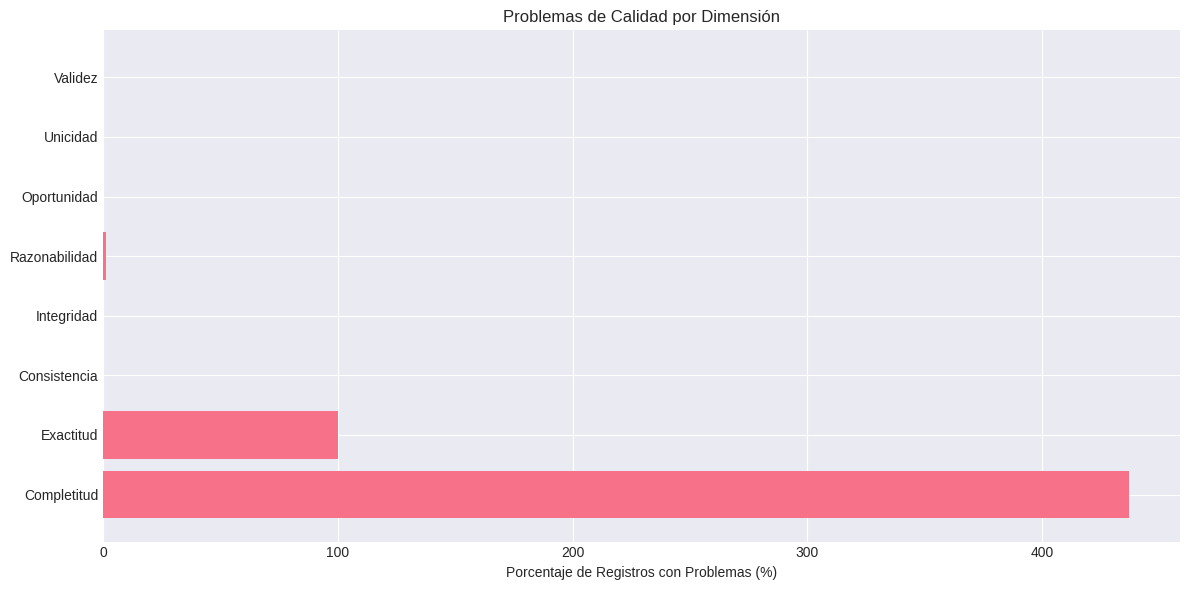

In [13]:
# Crear resumen
resumen = {
    'Dimensión': [
        'Completitud',
        'Exactitud',
        'Consistencia',
        'Integridad',
        'Razonabilidad',
        'Oportunidad',
        'Unicidad',
        'Validez'
    ],
    'Registros con Problemas': [
        missing_data.sum(),
        len(anios_invalidos) + len(meses_invalidos) + len(respuestas_negativas),
        len(resolucion_sin_fecha) + len(fecha_sin_resolucion) + len(anio_desc_incorrecto),
        len(ids_invalidos),
        len(respuestas_enteras_extremas) + len(respuestas_decimales_extremas),
        len(fechas_creacion_fuera_rango) + len(fechas_resolucion_fuera_rango),
        len(duplicados_exactos),
        len(correos_invalidos) + len(estados_invalidos) + len(clasificaciones_invalidas) + len(indicadores_invalidos)
    ]
}

df_resumen = pd.DataFrame(resumen)
df_resumen['Porcentaje'] = (df_resumen['Registros con Problemas'] / len(df)) * 100


print("RESUMEN EJECUTIVO - CALIDAD DE DATOS")
print(df_resumen.to_string(index=False))

# Visualización del resumen
plt.figure(figsize=(12, 6))
plt.barh(df_resumen['Dimensión'], df_resumen['Porcentaje'])
plt.xlabel('Porcentaje de Registros con Problemas (%)')
plt.title('Problemas de Calidad por Dimensión')
plt.tight_layout()
plt.show()